In [52]:
import h5py, glob
import matplotlib.pyplot as plt
import agama
agama.setUnits(mass=1, length=1, velocity=1)
import numpy as np

files = glob.glob('/suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/*.h5')
for i,j in enumerate(files):
    print(i, files[i])

0 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-07_c10.h5


In [53]:
with h5py.File(files[0], 'r') as f:
    mcp_xv     = f['mcp_xv'][:]
    bound      = f['bound'][:]
    E_p        = f['E_p'][:]
    mc_xv      = f['mc_xv'][:]
    snap_times = f['snap_times'][:]
    
    mcp_mass        = f.attrs['mcp_mass']
    Nbody           = f.attrs['Nbody']
    simulation_time = f.attrs['simulation_time']
    tupd            = f.attrs['tupd']
    mc_mass         = f.attrs['mc_mass']
    mc_delta        = f.attrs['mc_delta']
    mc_radius       = f.attrs['mc_radius']
    mc_radius_char  = f.attrs['mc_radius_char']
    mc_density_char = f.attrs['mc_density_char']
    mc_concentration= f.attrs['mc_concentration']
    ic=f.attrs['ic']


In [54]:
mcp_xv 

array([[[-1.41159102e-08, -2.40411613e-09, -1.92075511e-09,
          6.35997689e-03,  3.74273226e-03, -9.11857490e-03],
        [-1.96880723e-08, -2.14658291e-11,  2.12089724e-09,
          7.19223598e-03,  7.86294512e-03, -5.00569963e-04],
        [-2.01017534e-08,  4.58301785e-10, -4.16530455e-09,
          4.45572975e-03, -1.41180903e-03, -4.95571433e-04],
        ...,
        [-1.75806396e-08, -1.35149103e-09,  8.57873772e-10,
          8.97725164e-03,  2.14552699e-03, -9.77144776e-03],
        [-1.77729231e-08, -1.98366884e-09,  1.66289205e-09,
          6.66406278e-03, -1.13590607e-02, -3.50722010e-03],
        [-1.78339865e-08, -1.44176032e-09,  1.29825928e-09,
         -6.70933330e-03,  2.50084839e-03,  7.01759328e-03]],

       [[ 8.76674000e-04,  2.07783893e-06,  6.66261617e-05,
         -1.13440118e-02, -4.10456034e-03,  1.82454905e-02],
        [ 7.20106516e-04, -7.28506711e-05,  2.58059431e-04,
         -4.60116529e-03, -7.67520187e-03,  1.33875673e-02],
        [ 4.00444

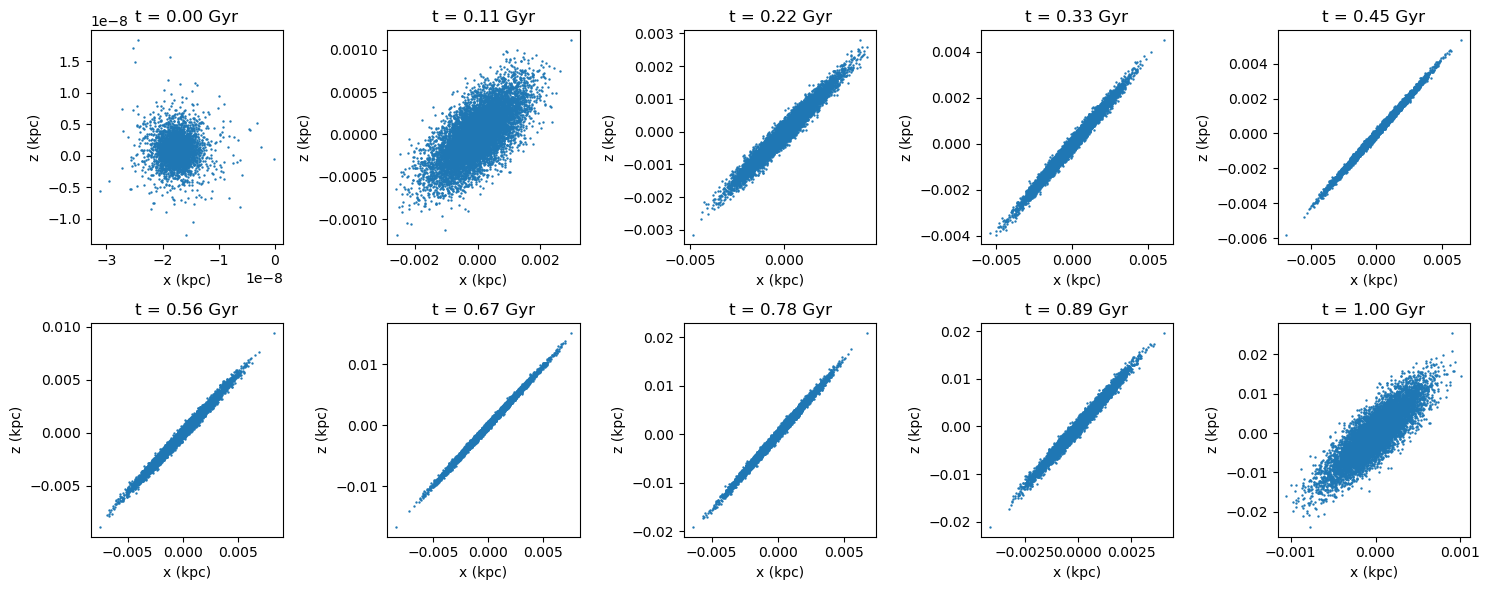

0.001


In [55]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.scatter(mcp_xv[i, :, 0], mcp_xv[i, :, 2], s=0.5)
    ax.set_title(f't = {snap_times[i]:.2f} Gyr')
    ax.set_xlabel('x (kpc)')
    ax.set_ylabel('z (kpc)')

plt.tight_layout()
plt.show()
print(tupd)

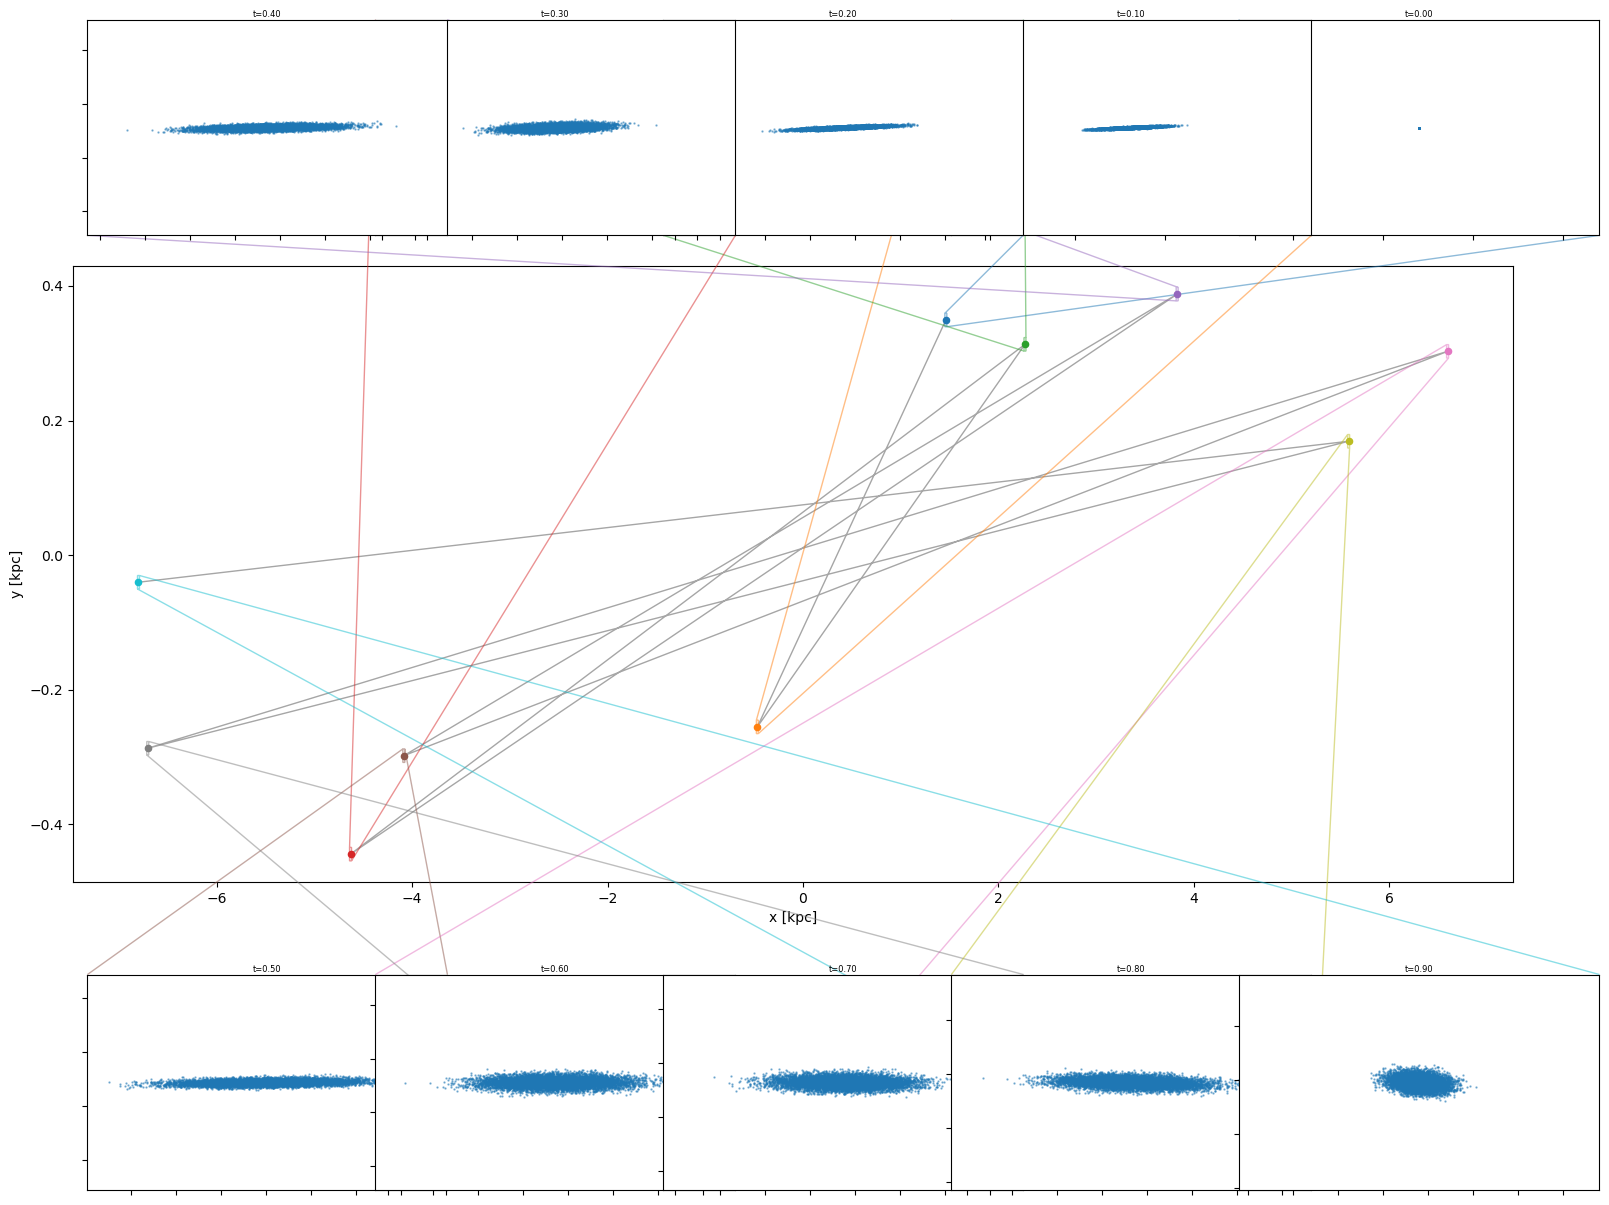

In [11]:
fig, ax = plt.subplots(figsize=(18, 14))
fig.subplots_adjust(left=0.1, right=0.9, top=0.72, bottom=0.28)

ax.plot(mc_xv[:, 0], mc_xv[:, 1], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

# 5 above, 5 below
inset_positions = (
    [[0.01 + 0.2*i, 1.05, 0.25, 0.35] for i in range(4, -1, -1)] +
    [[0.01 + 0.2*i, -0.50, 0.25, 0.35] for i in range(5)]
)




for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, 0] + mc_xv[i, 0], mcp_xv[i, :, 1] + mc_xv[i, 1], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    x_c = mcp_xv[i, :, 0].mean() + mc_xv[i, 0]
    y_c = mcp_xv[i, :, 1].mean() + mc_xv[i, 1]
    dx = max(mcp_xv[i, :, 0].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, 1].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    ax.scatter(mc_xv[i, 0], mc_xv[i, 1], s=20, zorder=5, color=f'C{i}')
    ax.indicate_inset_zoom(axz, edgecolor=f'C{i}')

plt.show()


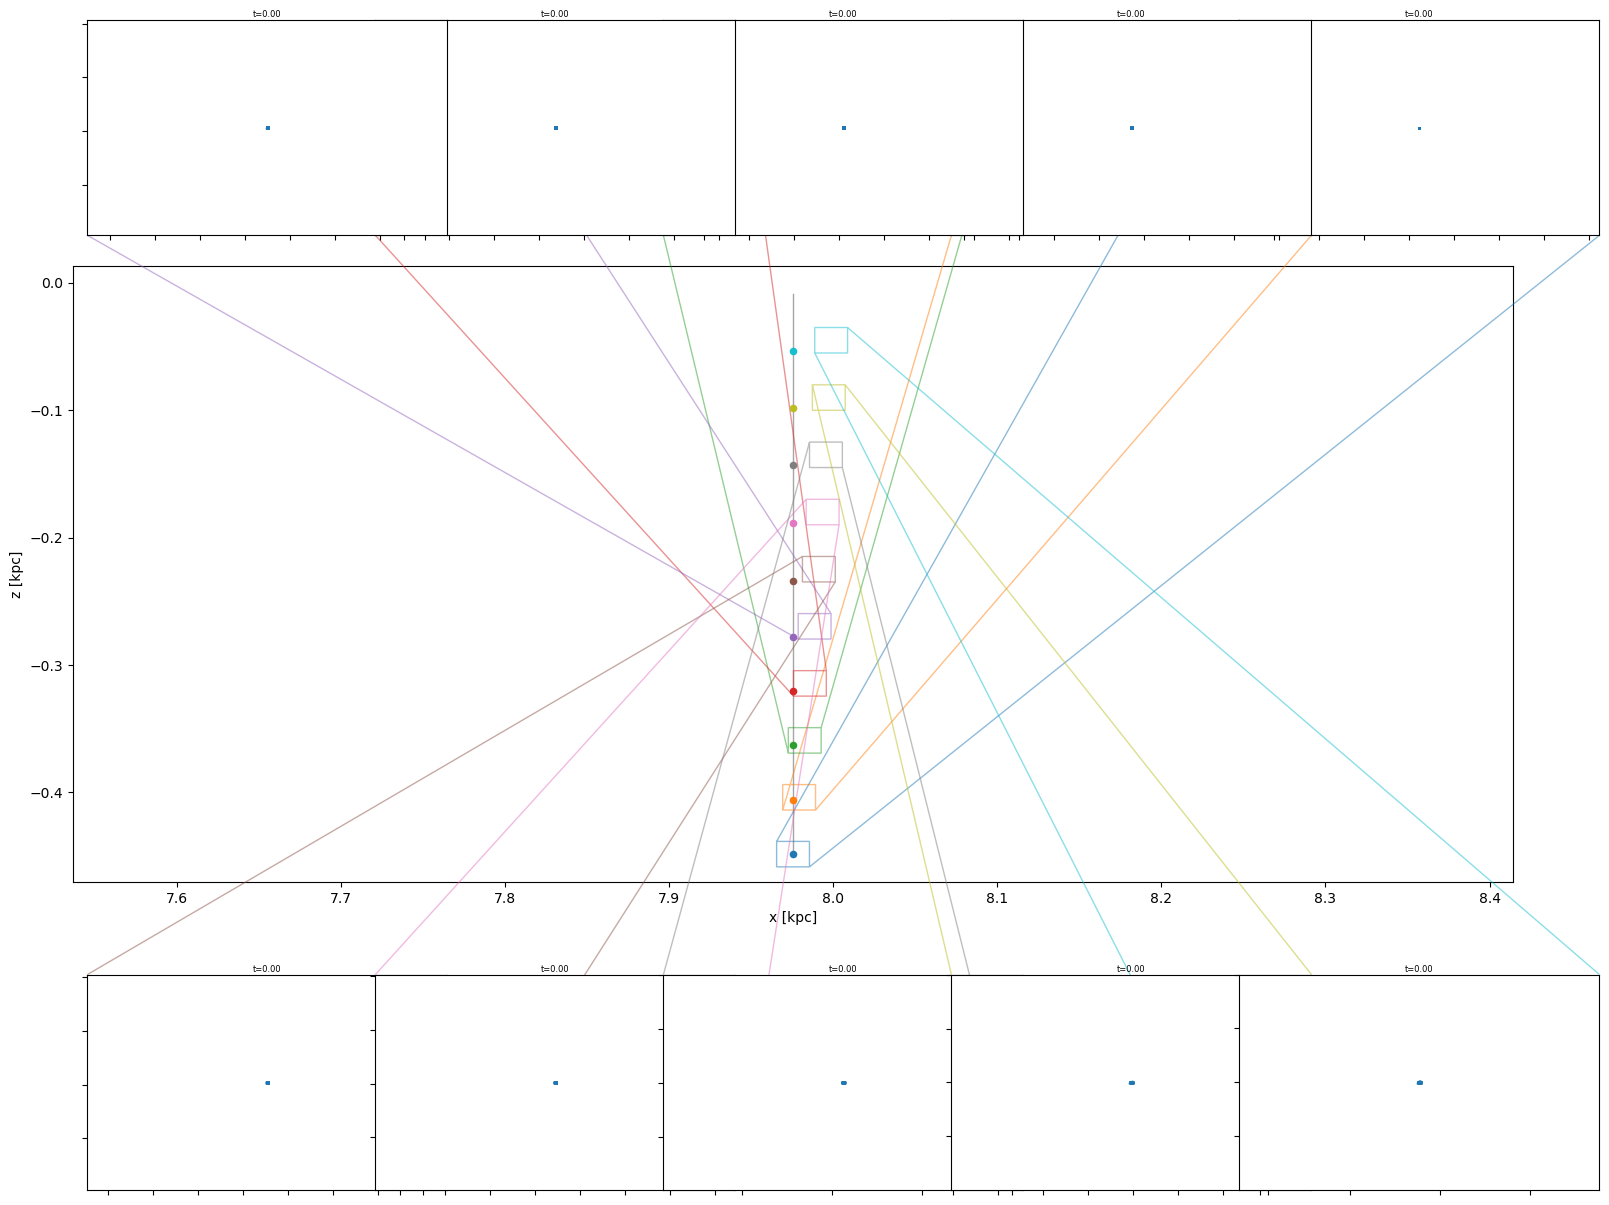

In [53]:
x, y = 0, 2

fig, ax = plt.subplots(figsize=(18, 14))
fig.subplots_adjust(left=0.1, right=0.9, top=0.72, bottom=0.28)

ax.plot(mc_xv[:, x], mc_xv[:, y], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')

inset_positions = (
    [[0.01 + 0.2*i, 1.05, 0.25, 0.35] for i in range(4, -1, -1)] +
    [[0.01 + 0.2*i, -0.50, 0.25, 0.35] for i in range(5)]
)

for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, x] + mc_xv[i, x], mcp_xv[i, :, y] + mc_xv[i, y], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    x_c = mcp_xv[i, :, x].mean() + mc_xv[i, x]
    y_c = mcp_xv[i, :, y].mean() + mc_xv[i, y]
    dx = max(mcp_xv[i, :, x].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, y].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    ax.scatter(mc_xv[i, x], mc_xv[i, y], s=20, zorder=5, color=f'C{i}')
    ax.indicate_inset_zoom(axz, edgecolor=f'C{i}')

plt.show()


IndexError: index 9 is out of bounds for axis 0 with size 9

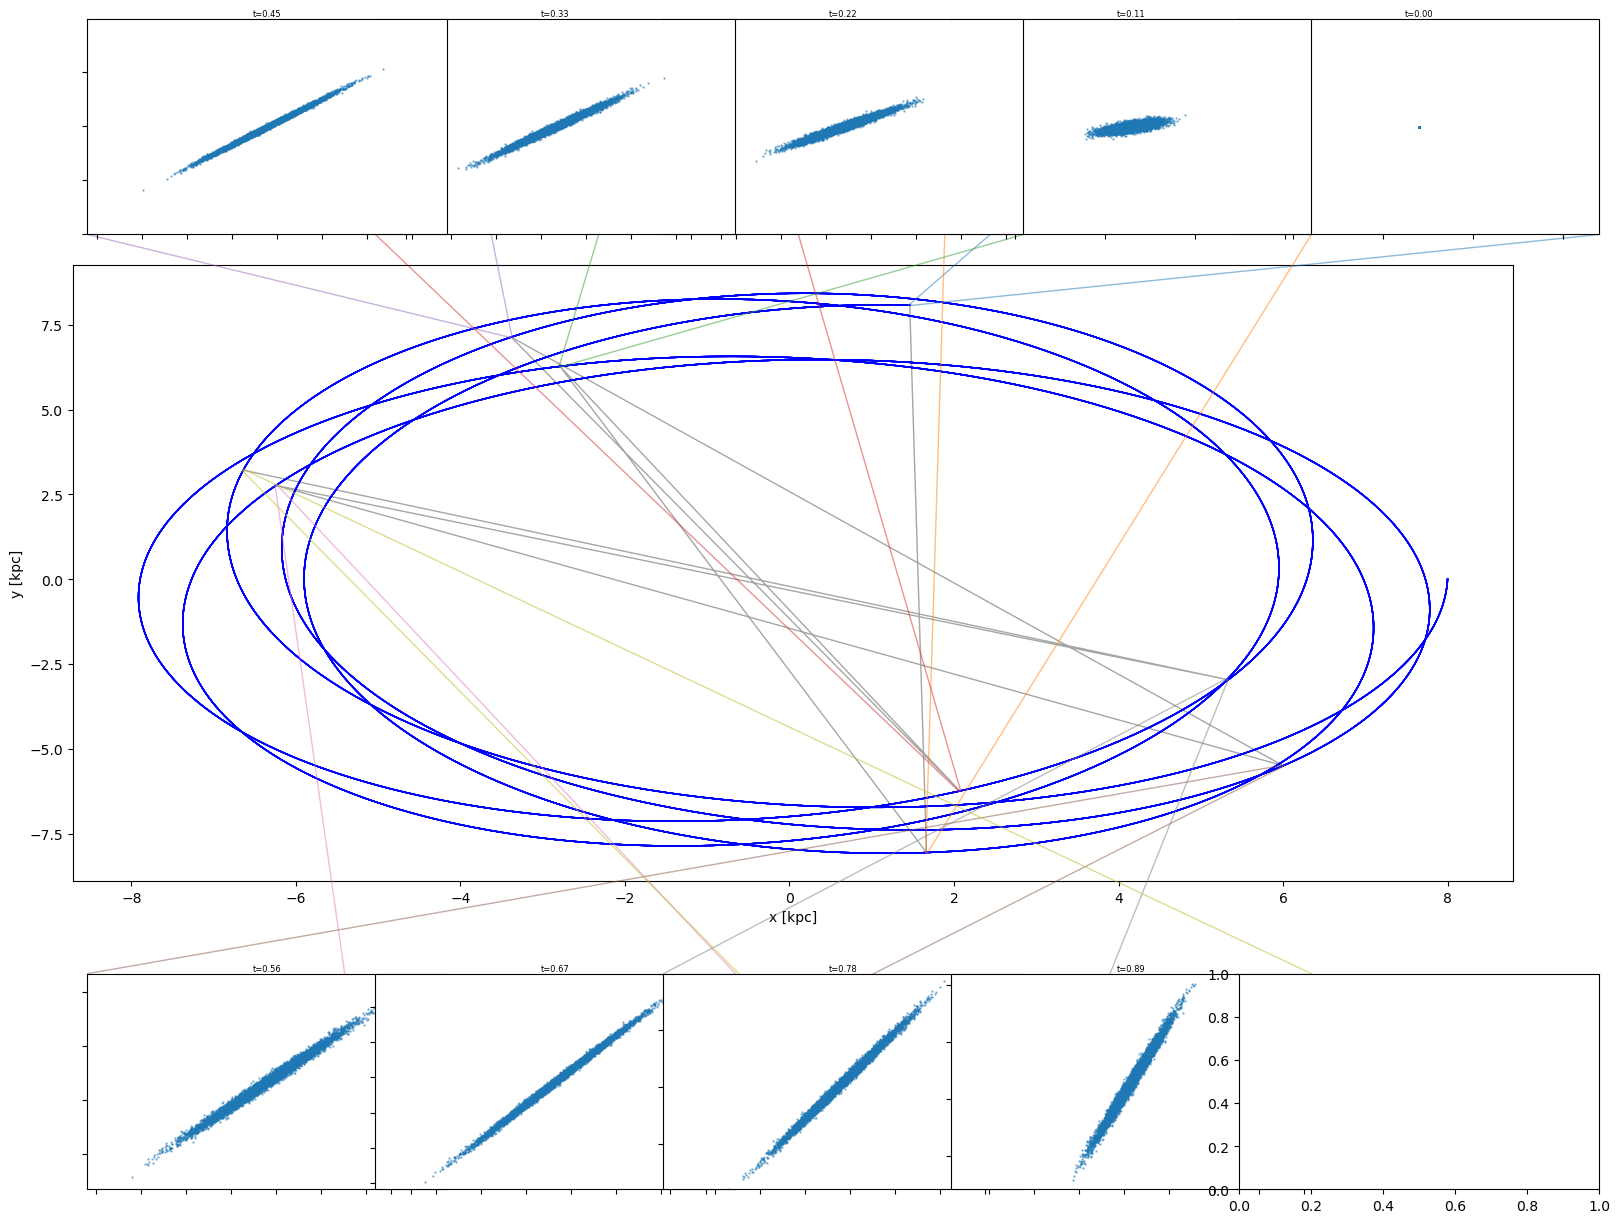

In [51]:
x, y = 0,2 

fig, ax = plt.subplots(figsize=(18, 14))
fig.subplots_adjust(left=0.1, right=0.9, top=0.72, bottom=0.28)

ax.plot(mc_xv[:, x], mc_xv[:, y], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

inset_positions = (
    [[0.01 + 0.2*i, 1.05, 0.25, 0.35] for i in range(4, -1, -1)] +
    [[0.01 + 0.2*i, -0.50, 0.25, 0.35] for i in range(5)]
)

for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, x] + mc_xv[i, x], mcp_xv[i, :, y] + mc_xv[i, y], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    x_c = mcp_xv[i, :, x].mean() + mc_xv[i, x]
    y_c = mcp_xv[i, :, y].mean() + mc_xv[i, y]
    dx = max(mcp_xv[i, :, x].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, y].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])
    ax.plot(s_orbit(t)[:,0],s_orbit(t)[:,2], lw=1, color='blue')
    #ax.scatter(mc_xv[i, x], mc_xv[i, y], s=20, zorder=5, color=f'C{i}')
    ax.indicate_inset_zoom(axz, edgecolor=f'C{i}')

plt.show()


In [25]:
pot_mw = agama.Potential('/suphys/aani0116/minicluster/minicluster_tidal/Agama/data/McMillan17.ini')
s_orbit = agama.orbit(ic=ic, potential=pot_mw, time=simulation_time,dtype=object)


In [29]:
t=np.linspace(0, simulation_time, 10000)


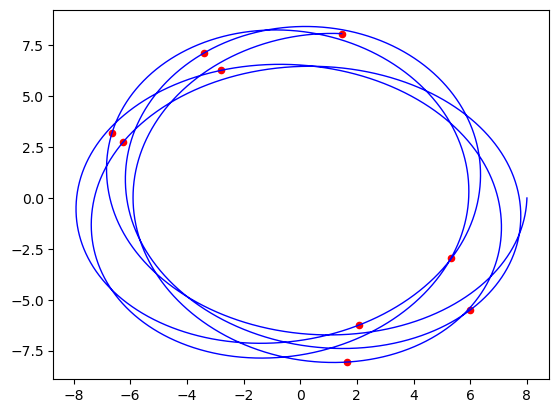

In [50]:
plt.plot(s_orbit(t)[:,0],s_orbit(t)[:,2], lw=1, color='blue')
plt.scatter(mc_xv[:, 0], mc_xv[:, 2], color='red', s=20)

In [45]:
snapshot_times = np.linspace(0, simulation_time, 10 )


In [46]:
snapshot_times

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

In [35]:
ic

array([   1.4620053 ,    0.34935287,    8.076491  , -174.98038   ,
        -14.4526825 ,   10.201319  ], dtype=float32)